In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
train_path = Path("../data/raw/imdb_train.csv")
test_path = Path("../data/raw/imdb_test.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Training set shape:", train_df.shape)
print("Test set shape:", test_df.shape)

Training set shape: (25000, 2)
Test set shape: (25000, 2)


In [3]:
train_df.head()

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [4]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    25000 non-null  str  
 1   label   25000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 32.0 MB


In [5]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    25000 non-null  str  
 1   label   25000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 31.2 MB


In [6]:
print("Training missing values:")
print(train_df.isnull().sum())

print("\nTest missing values:")
print(test_df.isnull().sum())

Training missing values:
text     0
label    0
dtype: int64

Test missing values:
text     0
label    0
dtype: int64


In [7]:
print(train_df["label"].value_counts())

label
0    12500
1    12500
Name: count, dtype: int64


In [8]:
print(train_df["label"].value_counts(normalize=True))

label
0    0.5
1    0.5
Name: proportion, dtype: float64


In [9]:
print("LABEL 0 EXAMPLE")
print(train_df[train_df["label"] == 0]["text"].iloc[0])

print("\n" + "=" * 80 + "\n")

print("LABEL 1 EXAMPLE")
print(train_df[train_df["label"] == 1]["text"].iloc[0])

LABEL 0 EXAMPLE
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and 

In [10]:
print(
    "Duplicate training reviews:",
    train_df["text"].duplicated().sum()
)

print(
    "Duplicate test reviews:",
    test_df["text"].duplicated().sum()
)

Duplicate training reviews: 96
Duplicate test reviews: 199


In [11]:
overlap = set(train_df["text"]).intersection(set(test_df["text"]))

print("Train/test overlapping reviews:", len(overlap))

Train/test overlapping reviews: 123


In [12]:
train_df["word_count"] = train_df["text"].str.split().str.len()

In [13]:
train_df["word_count"].describe()

count    25000.000000
mean       233.787200
std        173.733032
min         10.000000
25%        127.000000
50%        174.000000
75%        284.000000
max       2470.000000
Name: word_count, dtype: float64

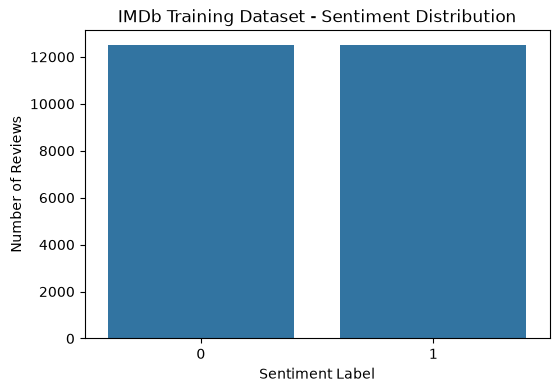

In [14]:
plt.figure(figsize=(6, 4))

sns.countplot(data=train_df, x="label")

plt.title("IMDb Training Dataset - Sentiment Distribution")
plt.xlabel("Sentiment Label")
plt.ylabel("Number of Reviews")

plt.show()

In [15]:
# Find reviews that appear in both training and test sets
train_texts = set(train_df["text"])
test_texts = set(test_df["text"])

overlapping_texts = train_texts.intersection(test_texts)

print("Number of overlapping reviews:", len(overlapping_texts))

# Create a dataframe showing the overlapping reviews
overlap_df = train_df[train_df["text"].isin(overlapping_texts)].merge(
    test_df[test_df["text"].isin(overlapping_texts)],
    on="text",
    suffixes=("_train", "_test")
)

print("\nOverlap shape:", overlap_df.shape)

overlap_df.head()

Number of overlapping reviews: 123

Overlap shape: (123, 4)


,text,label_train,word_count,label_test
0,Whoever wrote the screenplay for this movie ob...,0,114,0
1,"When I first saw a glimpse of this movie, I qu...",0,301,0
2,The stranger Jack (Matthew Lillard) arrives in...,0,194,0
3,It's unlikely that anyone except those who ado...,0,396,0
4,This movie really shows its age. The print I s...,0,300,0


In [16]:
overlap_df["labels_match"] = (
    overlap_df["label_train"] == overlap_df["label_test"]
)

print(
    "Overlapping reviews with matching labels:",
    overlap_df["labels_match"].sum()
)

print(
    "Overlapping reviews with conflicting labels:",
    (~overlap_df["labels_match"]).sum()
)

Overlapping reviews with matching labels: 123
Overlapping reviews with conflicting labels: 0


In [17]:
print("Before removing duplicates:")
print("Train:", len(train_df))
print("Test:", len(test_df))

train_df = train_df.drop_duplicates(subset="text").copy()
test_df = test_df.drop_duplicates(subset="text").copy()

print("\nAfter removing duplicates:")
print("Train:", len(train_df))
print("Test:", len(test_df))

Before removing duplicates:
Train: 25000
Test: 25000

After removing duplicates:
Train: 24904
Test: 24801


In [18]:
train_texts = set(train_df["text"])

test_before = len(test_df)

test_df = test_df[
    ~test_df["text"].isin(train_texts)
].copy()

test_after = len(test_df)

print("Test examples before removing overlap:", test_before)
print("Test examples after removing overlap:", test_after)
print("Overlapping examples removed:", test_before - test_after)

Test examples before removing overlap: 24801
Test examples after removing overlap: 24678
Overlapping examples removed: 123


In [19]:
train_texts = set(train_df["text"])
test_texts = set(test_df["text"])

remaining_overlap = train_texts.intersection(test_texts)

print("Remaining train/test overlap:", len(remaining_overlap))

Remaining train/test overlap: 0


In [20]:
print("Training distribution:")
print(train_df["label"].value_counts())

print("\nTest distribution:")
print(test_df["label"].value_counts())

print("\nTraining proportions:")
print(train_df["label"].value_counts(normalize=True))

print("\nTest proportions:")
print(test_df["label"].value_counts(normalize=True))

Training distribution:
label
1    12472
0    12432
Name: count, dtype: int64

Test distribution:
label
1    12412
0    12266
Name: count, dtype: int64

Training proportions:
label
1    0.500803
0    0.499197
Name: proportion, dtype: float64

Test proportions:
label
1    0.502958
0    0.497042
Name: proportion, dtype: float64


In [21]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

print("scikit-learn components imported successfully!")

scikit-learn components imported successfully!


In [22]:
X_train = train_df["text"]
y_train = train_df["label"]

X_test = test_df["text"]
y_test = test_df["label"]

print("Training examples:", len(X_train))
print("Test examples:", len(X_test))

Training examples: 24904
Test examples: 24678


In [23]:
model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000
        )
    )
])

print(model)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, min_df=2, ngram_range=(1, 2))),
                ('classifier', LogisticRegression(max_iter=1000))])


In [24]:
print("Training model...")

model.fit(X_train, y_train)

print("Training completed!")

Training model...
Training completed!


In [25]:
tfidf = model.named_steps["tfidf"]

print("Number of TF-IDF features:", len(tfidf.get_feature_names_out()))

Number of TF-IDF features: 435769


In [26]:
y_pred = model.predict(X_test)

print("Predictions generated:", len(y_pred))

Predictions generated: 24678


In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [28]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Accuracy:  0.8901
Precision: 0.8861
Recall:    0.8966
F1-score:  0.8914


In [29]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.89      0.88      0.89     12266
    Positive       0.89      0.90      0.89     12412

    accuracy                           0.89     24678
   macro avg       0.89      0.89      0.89     24678
weighted avg       0.89      0.89      0.89     24678



In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[10836  1430]
 [ 1283 11129]]


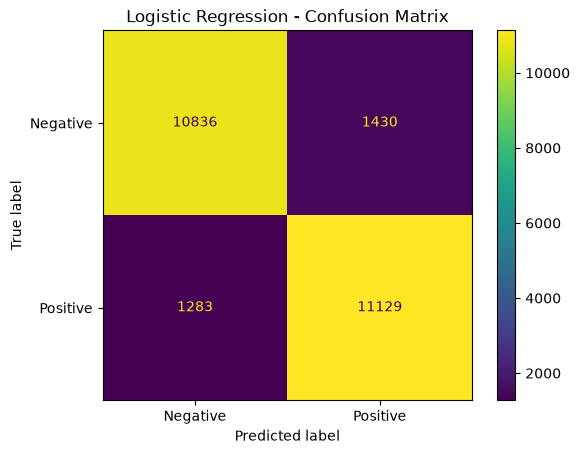

In [31]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [32]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

In [33]:
tfidf_params = {
    "lowercase": True,
    "ngram_range": (1, 2),
    "min_df": 2,
    "max_df": 0.95
}

In [34]:
nb_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(**tfidf_params)
    ),
    (
        "classifier",
        MultinomialNB()
    )
])

In [35]:
lr_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(**tfidf_params)
    ),
    (
        "classifier",
        LogisticRegression(max_iter=1000)
    )
])

In [36]:
svm_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(**tfidf_params)
    ),
    (
        "classifier",
        LinearSVC()
    )
])

In [37]:
print("Training Naive Bayes...")

nb_model.fit(X_train, y_train)

print("Naive Bayes training complete!")

Training Naive Bayes...
Naive Bayes training complete!


In [38]:
nb_pred = nb_model.predict(X_test)

In [39]:
nb_accuracy = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(y_test, nb_pred)
nb_recall = recall_score(y_test, nb_pred)
nb_f1 = f1_score(y_test, nb_pred)

print(f"Accuracy:  {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall:    {nb_recall:.4f}")
print(f"F1-score:  {nb_f1:.4f}")

Accuracy:  0.8683
Precision: 0.9023
Recall:    0.8279
F1-score:  0.8635


In [40]:
print("Training Linear SVM...")

svm_model.fit(X_train, y_train)

print("Linear SVM training complete!")

Training Linear SVM...
Linear SVM training complete!


In [41]:
svm_pred = svm_model.predict(X_test)

In [42]:
svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred)
svm_recall = recall_score(y_test, svm_pred)
svm_f1 = f1_score(y_test, svm_pred)

print(f"Accuracy:  {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall:    {svm_recall:.4f}")
print(f"F1-score:  {svm_f1:.4f}")

Accuracy:  0.9019
Precision: 0.9046
Recall:    0.8999
F1-score:  0.9022


In [43]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy,
        nb_accuracy,
        svm_accuracy
    ],
    "Precision": [
        precision,
        nb_precision,
        svm_precision
    ],
    "Recall": [
        recall,
        nb_recall,
        svm_recall
    ],
    "F1": [
        f1,
        nb_f1,
        svm_f1
    ]
})

comparison.sort_values(
    by="F1",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1
2,Linear SVM,0.901896,0.904592,0.899855,0.902217
0,Logistic Regression,0.890064,0.886137,0.896632,0.891354
1,Naive Bayes,0.868344,0.902274,0.827908,0.863493


In [44]:
results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)

comparison.to_csv(
    results_dir / "model_comparison.csv",
    index=False
)

print("Model comparison saved.")

Model comparison saved.


In [45]:
error_df = pd.DataFrame({
    "text": X_test.values,
    "actual": y_test.values,
    "predicted": svm_pred
})

error_df["correct"] = (
    error_df["actual"] == error_df["predicted"]
)

print("Total test examples:", len(error_df))
print("Correct predictions:", error_df["correct"].sum())
print("Incorrect predictions:", (~error_df["correct"]).sum())

Total test examples: 24678
Correct predictions: 22257
Incorrect predictions: 2421


In [46]:
incorrect_df = error_df[
    ~error_df["correct"]
].copy()

incorrect_df.head(10)

,text,actual,predicted,correct
4,"First off let me say, If you haven't enjoyed a...",0,1,False
18,"Ben, (Rupert Grint), is a deeply unhappy adole...",0,1,False
32,I'm the type of guy who loves hood movies from...,0,1,False
65,"It's Saturday, it's raining, and I think every...",0,1,False
78,"Maniratnam, who in India, is often compared wi...",0,1,False
84,"Like 'Singin' in the Rain', 'Cover Girl' has a...",0,1,False
87,"Formulaic slasher film, only this one stars th...",0,1,False
96,Might end up being the biggest disappointment ...,0,1,False
101,Julie Andrews satirically prods her own goody-...,0,1,False
103,David Bryce's comments nearby are exceptionall...,0,1,False


In [47]:
false_positives = error_df[
    (error_df["actual"] == 0) &
    (error_df["predicted"] == 1)
]

print("False positives:", len(false_positives))

false_positives.head(10)

False positives: 1178


,text,actual,predicted,correct
4,"First off let me say, If you haven't enjoyed a...",0,1,False
18,"Ben, (Rupert Grint), is a deeply unhappy adole...",0,1,False
32,I'm the type of guy who loves hood movies from...,0,1,False
65,"It's Saturday, it's raining, and I think every...",0,1,False
78,"Maniratnam, who in India, is often compared wi...",0,1,False
84,"Like 'Singin' in the Rain', 'Cover Girl' has a...",0,1,False
87,"Formulaic slasher film, only this one stars th...",0,1,False
96,Might end up being the biggest disappointment ...,0,1,False
101,Julie Andrews satirically prods her own goody-...,0,1,False
103,David Bryce's comments nearby are exceptionall...,0,1,False


In [48]:
false_negatives = error_df[
    (error_df["actual"] == 1) &
    (error_df["predicted"] == 0)
]

print("False negatives:", len(false_negatives))

false_negatives.head(10)

False negatives: 1243


,text,actual,predicted,correct
12277,It is more a subtle story of the fact that in ...,1,0,False
12280,This was a bold movie to hit Indian cinemas wh...,1,0,False
12284,The theme is controversial and the depiction o...,1,0,False
12292,"This is a very, very odd film...one that is so...",1,0,False
12313,"The ""good news"" is that the circus is in town....",1,0,False
12330,It really is a great film (after being able to...,1,0,False
12385,I'm a Petty Officer 1st Class (E-6) and have b...,1,0,False
12390,How many movies are there that you can think o...,1,0,False
12419,"To be brief, the story is paper thin and you c...",1,0,False
12420,One night I was listening to talk radio and th...,1,0,False


In [49]:
decision_scores = svm_model.decision_function(X_test)

error_df["decision_score"] = decision_scores

In [50]:
uncertain_df = error_df.copy()

uncertain_df["uncertainty"] = (
    uncertain_df["decision_score"].abs()
)

uncertain_df = uncertain_df.sort_values(
    "uncertainty"
)

uncertain_df[
    ["text", "actual", "predicted", "decision_score"]
].head(10)

,text,actual,predicted,decision_score
16732,"A good x evil film with tastes of ""James Bond""...",1,0,-0.000005
12917,You'll either love or hate movies such as this...,1,1,0.000098
11489,"The original ""Psycho"" (1960) is widely conside...",0,1,0.000267
11940,Empty shortening of John Irving's novel strive...,0,0,-0.000273
1279,What is it now-a-days that minority comedians ...,0,0,-0.000369
13005,Chris Morris' Brass Eye TV series had always g...,1,0,-0.000511
7131,Johnnie (Bert Wheeler) is a would-be songwrite...,0,1,0.000527
16575,1969 was the year. New York City was the place...,1,0,-0.000655
4469,I found my tape of this long forgotten 'show'....,0,1,0.000708
21258,"In this movie ""Virtual Sexuality"" the 17 year ...",1,0,-0.000734


In [51]:
print("False positives:", len(false_positives))
print("False negatives:", len(false_negatives))

False positives: 1178
False negatives: 1243


In [52]:
negative_errors = (
    (error_df["actual"] == 0) &
    (error_df["predicted"] == 1)
).sum()

positive_errors = (
    (error_df["actual"] == 1) &
    (error_df["predicted"] == 0)
).sum()

print(
    "Negative reviews incorrectly classified:",
    negative_errors
)

print(
    "Positive reviews incorrectly classified:",
    positive_errors
)

Negative reviews incorrectly classified: 1178
Positive reviews incorrectly classified: 1243


In [53]:
final_cm = confusion_matrix(
    y_test,
    svm_pred
)

print(final_cm)

[[11088  1178]
 [ 1243 11169]]


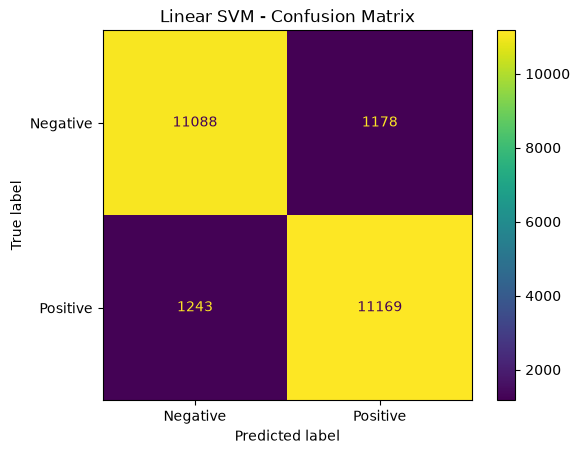

In [54]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()

plt.title("Linear SVM - Confusion Matrix")
plt.show()

<Figure size 600x500 with 0 Axes>

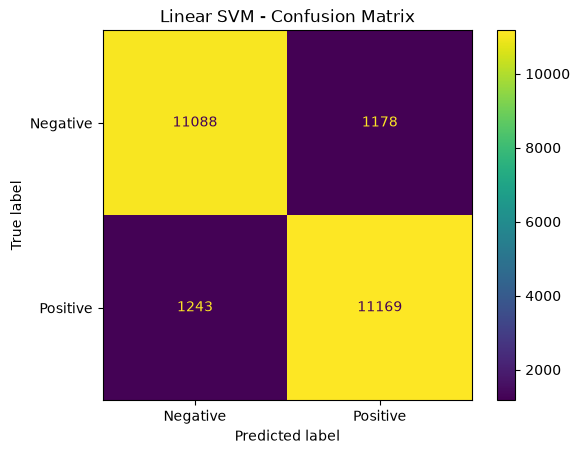

In [55]:
plt.figure(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()

plt.title("Linear SVM - Confusion Matrix")

plt.savefig(
    "../results/confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

In [56]:
import joblib

model_path = "../models/sentiment_model.joblib"

joblib.dump(svm_model, model_path)

print(f"Model saved to: {model_path}")

Model saved to: ../models/sentiment_model.joblib


In [57]:
from pathlib import Path

model_file = Path("../models/sentiment_model.joblib")

print("Exists:", model_file.exists())
print("Size:", model_file.stat().st_size, "bytes")

Exists: True
Size: 15030592 bytes


In [59]:
from pathlib import Path

processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

train_df.to_csv(processed_dir / "train_clean.csv", index=False)
test_df.to_csv(processed_dir / "test_clean.csv", index=False)

print("Cleaned datasets saved successfully!")
print("Train:", train_df.shape)
print("Test:", test_df.shape)

Cleaned datasets saved successfully!
Train: (24904, 3)
Test: (24678, 2)
